In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
atten_path= "/p/project1/hai_dnaori/piroozeh1/yeast-origins/data/OriDB_random_neg/train_dev_test_oridb/DNABERT2/result_matrix"
data_dir="/p/project1/hai_dnaori/piroozeh1/yeast-origins/data/OriDB_random_neg/train_dev_test_oridb"
atten_token= np.load(os.path.join(atten_path,"atten_token_based.npy"))
pred_results = np.load(os.path.join(atten_path,"pred_results.npy"))


data = pd.read_csv(os.path.join(data_dir,"test_window.tsv"),sep='\t',header=0)
data['pred'] = pred_results
data['pred'] = data['pred'].apply(lambda x: 1 if x>0.5 else 0)
file_path = os.path.join(atten_path,"tokenized_test_set.txt")
with open(file_path, 'r') as file:
    tokenized_set = file.read().split('\n')

tokens = [token.split() for i, token in enumerate(tokenized_set) if i in data.index]
data['tokens'] = tokens

data['seq_len'] = 0
for i, row in data.iterrows():
    seq = row['tokens']
    pads = 0
    pads += seq.count("[PAD]")
    len_seq = len(seq) - pads
    data.at[i, 'seq_len'] = len_seq

   
print(data.head())

   chr    start      end                                                seq  \
0   13   363312   363811  ATGCATTACAAATTTGTATTTGATTCTATATATAGTTTCGTTATAT...   
1    4   483669   484168  TTGATTTATACCATTTTGAAATCTAATCTTGCTCCAAGGGAGAAGC...   
2    7  1056150  1056649  CCTTGTAGTTGTCCTGCAAAGATGGGTAGGTATTTTCCTTGATATG...   
3   15   766442   766941  CAGTTTACAAGAATCACAACAAAAGGCGCCTTTGCAGAGGCCCCTT...   
4    4   638559   639058  CTCTAACTAATACAAACTCCTTACTATCTAATATAACGGCTACATC...   

   label  pred                                             tokens  seq_len  
0      0     0  [[CLS], A, TGCA, TTACAAA, TTTG, TATT, TGATT, C...      101  
1      1     0  [[CLS], TT, GATT, TATA, CCATTTT, GAAA, TCTAA, ...      106  
2      0     1  [[CLS], CCTT, GTAGTT, GTCCTG, CAAA, GATG, GGTA...      106  
3      1     1  [[CLS], CAGTT, TACAA, GAA, TCACAA, CAAAA, GGCG...       99  
4      0     0  [[CLS], CTCTAA, CTAA, TACAAA, CTCC, TTACTA, TC...      104  


In [4]:


dev_pos = data[data['label'] == 1]
dev_neg = data[data['label'] == 0]

pos_atten_token = atten_token[dev_pos.index.values]
neg_atten_token = atten_token[dev_neg.index.values]


dev_pos.reset_index(drop=True, inplace=True)
dev_neg.reset_index(drop=True, inplace=True)
print(dev_pos.head())
neg_atten_token.shape



   chr   start     end                                                seq  \
0    4  483669  484168  TTGATTTATACCATTTTGAAATCTAATCTTGCTCCAAGGGAGAAGC...   
1   15  766442  766941  CAGTTTACAAGAATCACAACAAAAGGCGCCTTTGCAGAGGCCCCTT...   
2   15  337119  337618  AAGAACCAGTGCAGGATATATATTATTTCCCACGGTTTTTCTCCAC...   
3    7  607176  607675  AAATAGAAGAGGTAAACCAATCAATGGCCCGTTAGTTTGCCATTTG...   
4    6  256090  256589  GCATGGAAGATATTCCGGGGTTGTTTAACAATAAACGTGTAGAGTA...   

   label  pred                                             tokens  seq_len  
0      1     0  [[CLS], TT, GATT, TATA, CCATTTT, GAAA, TCTAA, ...      106  
1      1     1  [[CLS], CAGTT, TACAA, GAA, TCACAA, CAAAA, GGCG...       99  
2      1     1  [[CLS], AA, GAA, CCAGTG, CAGGA, TATATA, TTATT,...      103  
3      1     1  [[CLS], AAA, TAGAA, GAGG, TAAA, CCAA, TCAATG, ...      102  
4      1     1  [[CLS], GCATG, GAAGA, TATT, CC, GGGGTT, GTT, T...      100  


(65, 114, 114)

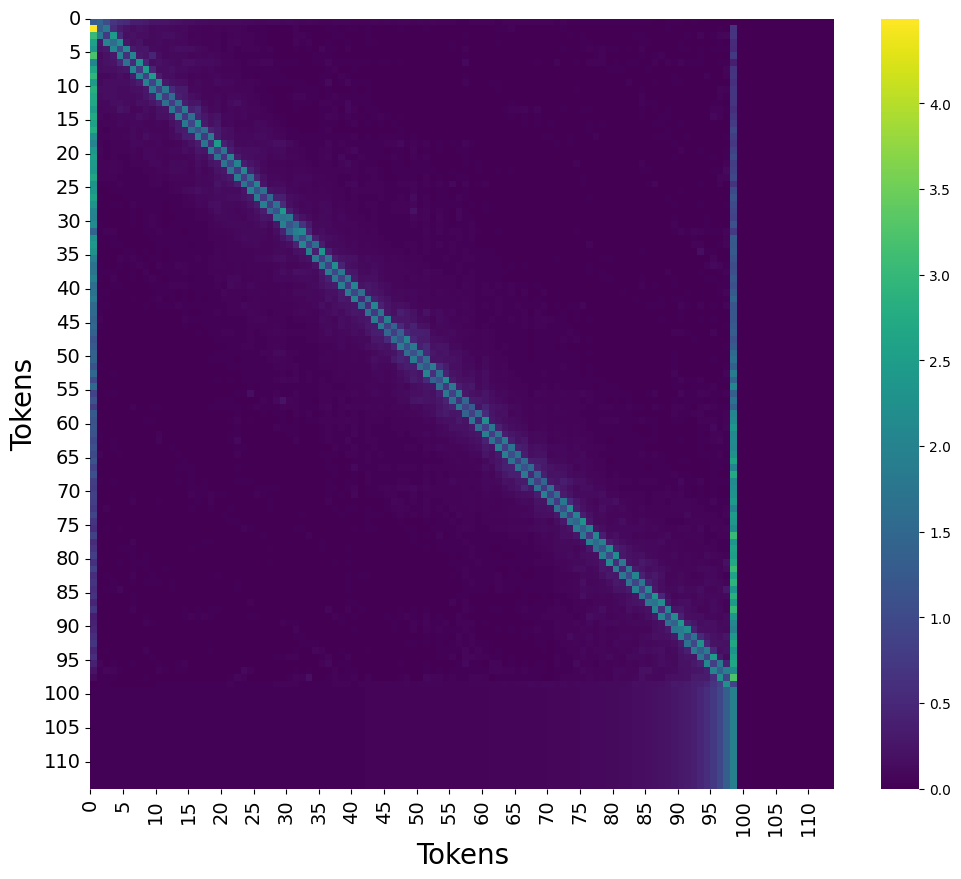

In [ ]:
# import seaborn as sns
# for i in range(10):
seq = dev_pos.iloc[1]
pos_atten_token_subset = pos_atten_token[1]

tokens=seq['tokens']
plt.figure(figsize=(12, 10))
sns.heatmap(pos_atten_token_subset,   cmap='viridis')
plt.xlabel('Tokens', fontsize=20)
plt.ylabel('Tokens', fontsize=20)
plt.tick_params(axis='both', which='major', labelsize=14)
n = pos_atten_token_subset.shape[0]
step = 5
ticks = np.arange(0, n, step)
plt.xticks(ticks, labels=ticks)
plt.yticks(ticks, labels=ticks)
# plt.title("Attention Heatmap for Tokenized Sequence chr{}-{}-{}, by DNABERT-2".format(str(seq['chr']), seq['start'], seq['end']))
plt.savefig("att_dnabert2_final.eps", dpi=300, bbox_inches='tight')
plt.savefig("att_dnabert2_final.png", dpi=300, bbox_inches='tight')
plt.show()
# plt.figure(figsize=(12, 10))
# sns.heatmap(pos_atten_token_subset[0:1, :],   cmap='viridis')
# plt.xlabel('Attention From Tokens')
# plt.ylabel('Attention to Tokens')
# plt.title("Attention Heatmap for 1 row DNA Sequence chr{}-{}-{}".format(str(seq['chr']), seq['start'], seq['end']))
# plt.show()
# plt.savefig("attheatmap_Large.eps", dpi=300, bbox_inches='tight')

# plt.figure(figsize=(12, 10))

